## House Pirce Prediction EDA


# 1) Problem Statement
This project predict the sales price for each house.

# 2) Data Collection
Data source: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview


# Import Panda,Numpy,Matplotlib,Seaborn,warning Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Read the dataset

In [2]:
df = pd.read_csv("data\house.csv")

# 5 row of dataset

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Shape of the dataset

In [4]:
df.shape

(1460, 81)

# Detail of the dataset

- **SalePrice**: The property's sale price in dollars. This is the target variable.
- **MSSubClass**: The building class
- **MSZoning**: The general zoning classification
- **LotFrontage**: Linear feet of street connected to property
- **LotArea**: Lot size in square feet
- **Street**: Type of road access
- **Alley**: Type of alley access
- **LotShape**: General shape of property
- **LandContour**: Flatness of the property
- **Utilities**: Type of utilities available
- **LotConfig**: Lot configuration
- **LandSlope**: Slope of property
- **Neighborhood**: Physical locations within Ames city limits
- **Condition1**: Proximity to main road or railroad
- **Condition2**: Proximity to main road or railroad (if second is present)
- **BldgType**: Type of dwelling
- **HouseStyle**: Style of dwelling
- **OverallQual**: Overall material and finish quality
- **OverallCond**: Overall condition rating
- **YearBuilt**: Original construction date
- **YearRemodAdd**: Remodel date
- **RoofStyle**: Type of roof
- **RoofMatl**: Roof material
- **Exterior1st**: Exterior covering on house
- **Exterior2nd**: Exterior covering on house (if more than one material)
- **MasVnrType**: Masonry veneer type
- **MasVnrArea**: Masonry veneer area in square feet
- **ExterQual**: Exterior material quality
- **ExterCond**: Present condition of the exterior material
- **Foundation**: Type of foundation
- **BsmtQual**: Height of the basement
- **BsmtCond**: General condition of the basement
- **BsmtExposure**: Walkout or garden level basement walls
- **BsmtFinType1**: Quality of basement finished area
- **BsmtFinSF1**: Type 1 finished square feet
- **BsmtFinType2**: Quality of second finished area
- **BsmtFinSF2**: Type 2 finished square feet
- **BsmtUnfSF**: Unfinished basement area (sq ft)
- **TotalBsmtSF**: Total basement area (sq ft)
- **Heating**: Type of heating
- **HeatingQC**: Heating quality and condition
- **CentralAir**: Central air conditioning
- **Electrical**: Electrical system
- **1stFlrSF**: First floor square feet
- **2ndFlrSF**: Second floor square feet
- **LowQualFinSF**: Low quality finished square feet
- **GrLivArea**: Above grade living area square feet
- **BsmtFullBath**: Basement full bathrooms
- **BsmtHalfBath**: Basement half bathrooms
- **FullBath**: Full bathrooms above grade
- **HalfBath**: Half baths above grade
- **Bedroom**: Number of bedrooms above basement
- **Kitchen**: Number of kitchens
- **KitchenQual**: Kitchen quality
- **TotRmsAbvGrd**: Total rooms above grade
- **Functional**: Home functionality rating
- **Fireplaces**: Number of fireplaces
- **FireplaceQu**: Fireplace quality
- **GarageType**: Garage location
- **GarageYrBlt**: Year garage was built
- **GarageFinish**: Interior finish of the garage
- **GarageCars**: Garage capacity (number of cars)
- **GarageArea**: Garage area in square feet
- **GarageQual**: Garage quality
- **GarageCond**: Garage condition
- **PavedDrive**: Paved driveway
- **WoodDeckSF**: Wood deck area in square feet
- **OpenPorchSF**: Open porch area in square feet
- **EnclosedPorch**: Enclosed porch area in square feet
- **3SsnPorch**: Three season porch area
- **ScreenPorch**: Screen porch area
- **PoolArea**: Pool area in square feet
- **PoolQC**: Pool quality
- **Fence**: Fence quality
- **MiscFeature**: Miscellaneous feature
- **MiscVal**: Value of miscellaneous feature
- **MoSold**: Month Sold
- **YrSold**: Year Sold
- **SaleType**: Type of sale
- **SaleCondition**: Condition of sale







# Data check to perform
- check Missing values
- check duplicate
- check data type
- Check the number of unique value of each column
- check statistics of dataseet
- check various categories in different column

# Check Missing values

In [10]:
((df.isnull().mean() * 100)).sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [11]:
col = [val for val in df.columns if df[val].isnull().mean() < 0.05 and df[val].isnull().mean() > 0 ]
col

['MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical']

#  All of the features have a relationship with the data also dataset is small so removing the those row
will cause data loss rather than we will impute the data set.

In [5]:
df.isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [6]:
missing_columns = df.columns[df.isna().any()]
missing_columns

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [7]:
df[missing_columns].isna().sum().sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

# Missing Percentage of the column

In [8]:
num_missing_columns = df[missing_columns].select_dtypes(exclude='object').columns
num_missing_columns

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='object')

In [9]:
num_missing_percentages = ((df[num_missing_columns].isna().sum())/len(df)*100).sort_values(ascending=False)
num_missing_percentages

LotFrontage    17.739726
GarageYrBlt     5.547945
MasVnrArea      0.547945
dtype: float64

# 1️⃣ LotFrontage (17.7% missing)

What it means:
Linear feet of street connected to the property.

The values vary a lot between neighborhoods, so using a simple median of the whole dataset is not ideal.

Better method (used by many ML engineers for this dataset):

Fill with median grouped by Neighborhood.

In [10]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [12]:
df["LotFrontage"].isna().sum()

np.int64(0)

# 2️⃣ GarageYrBlt (5.5% missing)

What it means:
Year the garage was built.

Missing values usually mean:

The house has no garage.

So the correct approach is:

Fill with 0.

In [13]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [14]:
df['GarageYrBlt'].isna().sum()

np.int64(0)

# 3️⃣ MasVnrArea (0.54% missing)

What it means:
Masonry veneer area.

Missing usually means:

No masonry veneer.

So fill with 0.

In [15]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [16]:
df[num_missing_columns].isna().sum().sort_values(ascending=False)

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

In [17]:
cat_missing_columns = df[missing_columns].select_dtypes(include='object').columns
cat_missing_columns

Index(['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC',
       'Fence', 'MiscFeature'],
      dtype='object')

In [18]:
cat_missing_percentage = ((df[cat_missing_columns].isna().sum())/len(df) * 100).sort_values(ascending=False)
cat_missing_percentage

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
GarageFinish     5.547945
GarageQual       5.547945
GarageType       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtFinType1     2.534247
BsmtCond         2.534247
Electrical       0.068493
dtype: float64

# 1️⃣ Extremely High Missing (Means Feature Does Not Exist)

These columns mean the house simply does not have that feature.

In [20]:
cols_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", 'MasVnrType']

for col in cols_none:
    df[col] = df[col].fillna("None")

In [21]:
garage_cols = ['GarageType','GarageFinish','GarageQual','GarageCond']
bsmt_cols = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']

for col in garage_cols + bsmt_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

5️⃣ Electrical (Very Small Missing)

Missing value:

0.06%

This is extremely small.

Best solution → fill with mode (most frequent value).

In [22]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [23]:
df.isnull().sum().sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

# Now no missing value in dataset

# Check Duplicate 

In [24]:
df.duplicated().sum()

np.int64(0)

## No duplicate value avilabe in here

# Data Type of the dataset

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [26]:
df.to_csv("data/house_cleaned.csv", index=False)

In [2]:
df = pd.read_csv("data/house_cleaned.csv")

In [3]:
df.isna().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

# Target Value Analysis

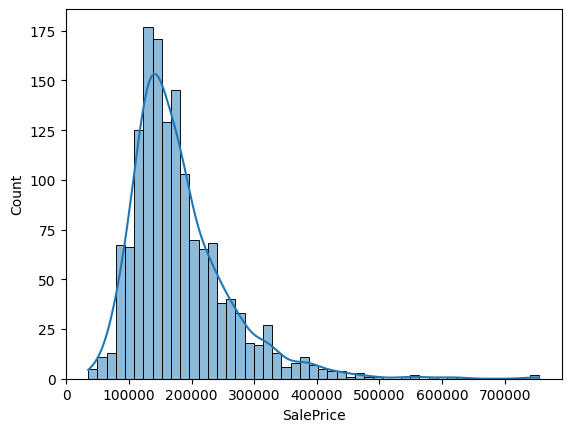

In [4]:
import seaborn as sns

sns.histplot(df["SalePrice"], kde=True)
plt.show()

# Distribution of SalesPrice column is right Skewed in the dataset.

Thats mean only few values are large so to do balance it i will peroform log transform on the target column

In [5]:
df["SalePrice"] = np.log1p(df["SalePrice"])

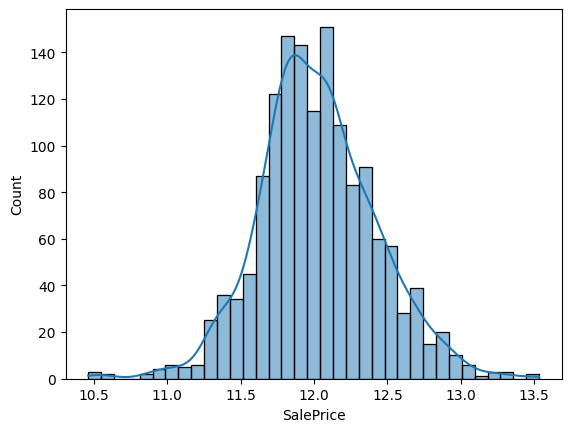

In [6]:
sns.histplot(df["SalePrice"], kde=True)
plt.show()

# Correlation Analysis

In [7]:
corr = df.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.426776
BsmtFinSF1       0.372023
LotFrontage      0.353288
GarageYrBlt      0.349013
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

# Top 5 features which has the great influence on the dataset
* OverallQual      0.817185 
* GrLivArea        0.700927
* GarageCars       0.680625
* GarageArea       0.650888
* TotalBsmtSF      0.612134

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

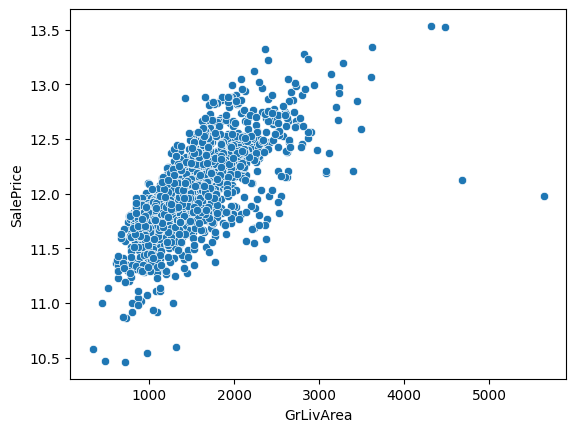

In [8]:
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])

# Two house with large Living Area has lower price which will make issue in future so remove those data will make the model better


In [9]:
df = df[df["GrLivArea"] < 4500]

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

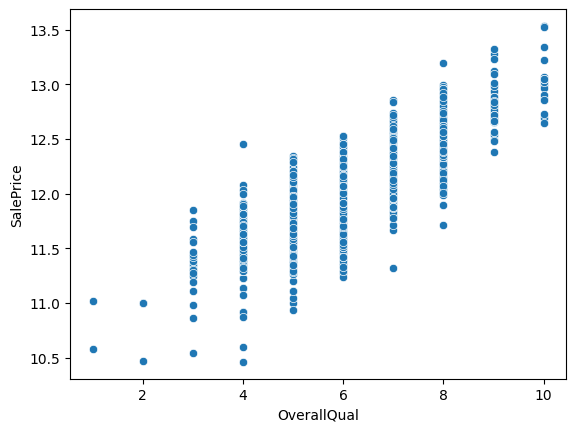

In [10]:
sns.scatterplot(x=df["OverallQual"], y=df["SalePrice"])

<Axes: xlabel='GarageArea', ylabel='SalePrice'>

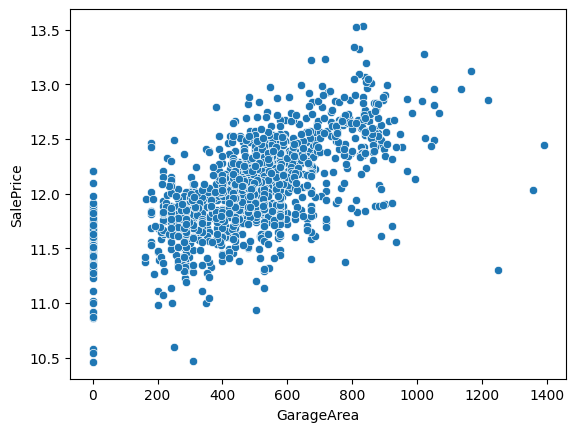

In [11]:
sns.scatterplot(x=df["GarageArea"], y=df["SalePrice"])

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

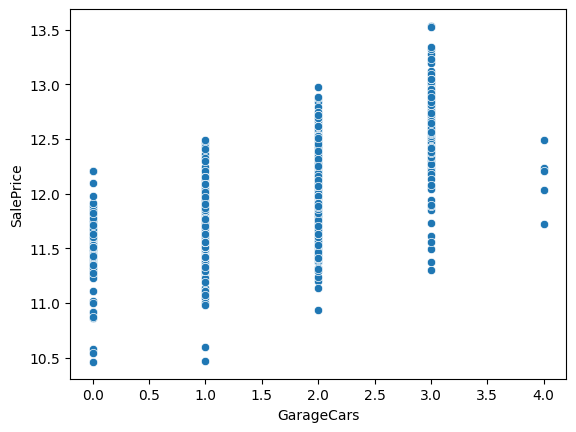

In [12]:
sns.scatterplot(x=df["GarageCars"], y=df["SalePrice"])

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

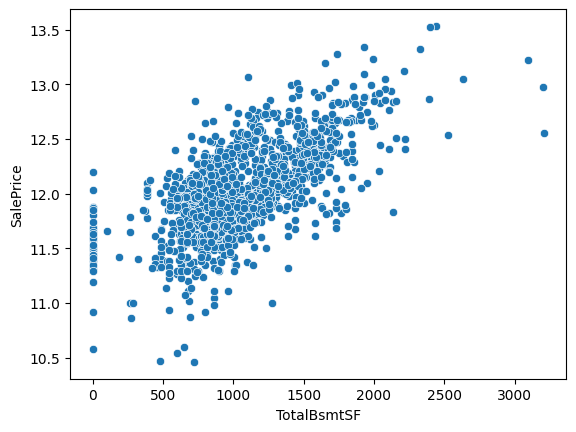

In [14]:
sns.scatterplot(x=df["TotalBsmtSF"], y=df["SalePrice"])

# EDA is done for this dataset

In [15]:
df.to_csv("data/house_cleaned_EDA.csv", index=False)

In [3]:
df = pd.read_csv("data/house_cleaned_EDA.csv")

In [4]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].nunique())

MSZoning 5
Street 2
Alley 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 7
Exterior1st 15
Exterior2nd 16
MasVnrType 3
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 4
BsmtCond 4
BsmtExposure 4
BsmtFinType1 6
BsmtFinType2 6
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 5
GarageType 6
GarageFinish 3
GarageQual 5
GarageCond 5
PavedDrive 3
PoolQC 3
Fence 4
MiscFeature 4
SaleType 9
SaleCondition 6


# Feature Engineering

In [5]:
df.drop(columns=["Id"], axis=1, inplace=True)

In [6]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220


In [4]:
cat_column = df.select_dtypes(include="object").columns
df[cat_column].nunique().sort_values(ascending=False)

Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
Condition2        8
RoofMatl          7
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64

In [15]:
for col in cat_column:
    print(f"{col} : {df[col].unique()}")

MSZoning : ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street : ['Pave' 'Grvl']
Alley : [nan 'Grvl' 'Pave']
LotShape : ['Reg' 'IR1' 'IR2' 'IR3']
LandContour : ['Lvl' 'Bnk' 'Low' 'HLS']
Utilities : ['AllPub' 'NoSeWa']
LotConfig : ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope : ['Gtl' 'Mod' 'Sev']
Neighborhood : ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Condition1 : ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2 : ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosA' 'PosN' 'RRAn' 'RRAe']
BldgType : ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle : ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle : ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl : ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll']
Exterior1st :

In [6]:
for col in cat_column:
    print(col)
    print(df[col].value_counts())
    print("-------------")

MSZoning
MSZoning
RL         1149
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
-------------
Street
Street
Pave    1452
Grvl       6
Name: count, dtype: int64
-------------
Alley
Alley
Grvl    50
Pave    41
Name: count, dtype: int64
-------------
LotShape
LotShape
Reg    925
IR1    483
IR2     41
IR3      9
Name: count, dtype: int64
-------------
LandContour
LandContour
Lvl    1311
Bnk      61
HLS      50
Low      36
Name: count, dtype: int64
-------------
Utilities
Utilities
AllPub    1457
NoSeWa       1
Name: count, dtype: int64
-------------
LotConfig
LotConfig
Inside     1051
Corner      262
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64
-------------
LandSlope
LandSlope
Gtl    1380
Mod      65
Sev      13
Name: count, dtype: int64
-------------
Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards     98
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW

In [8]:
for col in cat_column:
    print(f"{col}: {df[col].unique()}")

MSZoning: ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street: ['Pave' 'Grvl']
Alley: [nan 'Grvl' 'Pave']
LotShape: ['Reg' 'IR1' 'IR2' 'IR3']
LandContour: ['Lvl' 'Bnk' 'Low' 'HLS']
Utilities: ['AllPub' 'NoSeWa']
LotConfig: ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope: ['Gtl' 'Mod' 'Sev']
Neighborhood: ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Condition1: ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2: ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosA' 'PosN' 'RRAn' 'RRAe']
BldgType: ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle: ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle: ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl: ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll']
Exterior1st: ['VinylSd' 'Met

In [12]:
ordinal_cols = [
"ExterQual","ExterCond","BsmtQual","BsmtCond",
"BsmtExposure","BsmtFinType1","BsmtFinType2",
"HeatingQC","KitchenQual","FireplaceQu",
"GarageQual","GarageCond","GarageFinish",
"PoolQC","LandSlope","Functional","PavedDrive","Fence"
]

nominal_cols = [col for col in cat_column if col not in ordinal_cols]

# Quality / Condition Features (Use qual_map)

In [47]:
df[ordinal_cols] =df[ordinal_cols].fillna("None")

In [43]:
qual_cols = [
"ExterQual","ExterCond","HeatingQC","KitchenQual",
"FireplaceQu","GarageQual","GarageCond","PoolQC",
"BsmtQual","BsmtCond"
]

In [48]:
qual_map = {
"None":0,
"Po":1,
"Fa":2,
"TA":3,
"Gd":4,
"Ex":5
}

for col in qual_cols:
    df[col] = df[col].map(qual_map)

# Basement Exposure
Order: No < Mn < Av < Gd

In [15]:
bsmt_exposure_map = {
"None":0,
"No":1,
"Mn":2,
"Av":3,
"Gd":4
}

df["BsmtExposure"] = df["BsmtExposure"].map(bsmt_exposure_map)

# Basement Finish Type
Unf < LwQ < Rec < BLQ < ALQ < GLQ

In [16]:
bsmt_fin_map = {
"None":0,
"Unf":1,
"LwQ":2,
"Rec":3,
"BLQ":4,
"ALQ":5,
"GLQ":6
}

df["BsmtFinType1"] = df["BsmtFinType1"].map(bsmt_fin_map)
df["BsmtFinType2"] = df["BsmtFinType2"].map(bsmt_fin_map)

# Garage Finish

Order:

Unf < RFn < Fin

In [17]:
garage_finish_map = {
"None":0,
"Unf":1,
"RFn":2,
"Fin":3
}

df["GarageFinish"] = df["GarageFinish"].map(garage_finish_map)

# Land Slope

Order:

Sev < Mod < Gtl

In [18]:
land_slope_map = {
"Sev":1,
"Mod":2,
"Gtl":3
}

df["LandSlope"] = df["LandSlope"].map(land_slope_map)

# Paved Drive

Order:

N < P < Y

In [19]:
paved_map = {
"N":0,
"P":1,
"Y":2
}

df["PavedDrive"] = df["PavedDrive"].map(paved_map)

# Functional

Order:

Sal < Sev < Maj2 < Maj1 < Mod < Min2 < Min1 < Typ

In [20]:
functional_map = {
"Sal":1,
"Sev":2,
"Maj2":3,
"Maj1":4,
"Mod":5,
"Min2":6,
"Min1":7,
"Typ":8
}

df["Functional"] = df["Functional"].map(functional_map)

In [34]:
df['PoolQC'].head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: PoolQC, dtype: int64

In [36]:
df.isnull().sum().any()

np.True_

In [49]:
df[ordinal_cols]

,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,GarageFinish,PoolQC,LandSlope,Functional,PavedDrive,Fence
0,0,0,0,0,1.0,6.0,1.0,0,0,0,0,0,2.0,0,3,8,2,None
1,0,0,0,0,4.0,5.0,1.0,0,0,0,0,0,2.0,0,3,8,2,None
2,0,0,0,0,2.0,6.0,1.0,0,0,0,0,0,2.0,0,3,8,2,None
3,0,0,0,0,1.0,5.0,1.0,0,0,0,0,0,1.0,0,3,8,2,None
4,0,0,0,0,3.0,6.0,1.0,0,0,0,0,0,2.0,0,3,8,2,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,0,0,0,0,1.0,1.0,1.0,0,0,0,0,0,2.0,0,3,8,2,None
1454,0,0,0,0,1.0,5.0,3.0,0,0,0,0,0,1.0,0,3,7,2,MnPrv
1455,0,0,0,0,1.0,6.0,1.0,0,0,0,0,0,2.0,0,3,8,2,GdPrv
1456,0,0,0,0,2.0,6.0,3.0,0,0,0,0,0,1.0,0,3,8,2,None


In [50]:
df['Fence'] = df['Fence'].map({'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4})

In [51]:
df[ordinal_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,GarageFinish,PoolQC,LandSlope,Functional,PavedDrive,Fence
0,0,0,0,0,1.0,6.0,1.0,0,0,0,0,0,2.0,0,3,8,2,0
1,0,0,0,0,4.0,5.0,1.0,0,0,0,0,0,2.0,0,3,8,2,0
2,0,0,0,0,2.0,6.0,1.0,0,0,0,0,0,2.0,0,3,8,2,0
3,0,0,0,0,1.0,5.0,1.0,0,0,0,0,0,1.0,0,3,8,2,0
4,0,0,0,0,3.0,6.0,1.0,0,0,0,0,0,2.0,0,3,8,2,0


In [52]:
df.to_csv("data/house_cleaned.csv", index=False)